In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
df = pd.read_csv('https://raw.githubusercontent.com/sylviacoder/SmartCare-Healthcare-Insurance-Claim-Fraud-Detection-/refs/heads/main/data/raw/Health_Insurance.csv')

In [82]:
df.describe(include= 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,14604.0,NaN,NaN,NaN,39.547521,14.015966,18.0,27.0,40.0,52.0,64.0
sex,15000,2,female,7652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,15000.0,NaN,NaN,NaN,64.9096,13.701935,34.0,54.0,63.0,76.0,95.0
bmi,14044.0,NaN,NaN,NaN,30.266413,6.12295,16.0,25.7,29.4,34.4,53.1
hereditary_diseases,15000,10,NoDisease,13998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_dependents,15000.0,NaN,NaN,NaN,1.129733,1.228469,0.0,0.0,1.0,2.0,5.0
smoker,15000.0,NaN,NaN,NaN,0.198133,0.398606,0.0,0.0,0.0,0.0,1.0
city,15000,91,NewOrleans,302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bloodpressure,15000.0,NaN,NaN,NaN,68.650133,19.418515,0.0,64.0,71.0,80.0,122.0
diabetes,15000.0,NaN,NaN,NaN,0.777,0.416272,0.0,1.0,1.0,1.0,1.0


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


Missing values in 2 columns: age and bmi

In [86]:
df.isna().sum()

age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

Total of 396 missing values and 956 missing values in age and bmi columns respectively

In [88]:
df.head(2)

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0


In [90]:
print(df['smoker'].value_counts())
print(df['hereditary_diseases'].value_counts())
print(df['bmi'].unique())

smoker
0    12028
1     2972
Name: count, dtype: int64
hereditary_diseases
NoDisease       13998
Diabetes          148
Alzheimer         144
Obesity           136
EyeDisease        123
Cancer            109
Arthritis          96
HeartDisease       93
Epilepsy           84
High BP            69
Name: count, dtype: int64
[24.3 22.6 17.8 36.4 20.6 37.9 23.8 26.8  nan 29.6 33.  36.5 24.6 35.7
 18.9 40.3 27.2 41.3 38.4 28.5 31.8 31.3 25.7 25.3 24.8 39.4 25.5 26.9
 24.  37.1 44.8 25.1 32.3 28.7 35.2 26.7 26.4 22.3 25.8 21.9 40.2 38.6
 39.2 28.9 25.9 32.7 29.7 26.  35.6 46.8 34.2 23.1 31.6 40.9 27.6 22.9
 18.3 25.2 34.4 34.1 23.9 22.1 32.2 38.3 37.3 33.2 33.3 27.7 31.4 46.5
 35.3 27.5 23.5 21.5 20.2 21.8 34.3 39.8 38.1 32.  20.5 26.6 28.3 25.
 27.4 39.7 29.8 29.4 23.2 40.  17.5 20.1 18.5 24.1 43.3 36.  29.9 41.8
 31.  23.7 32.8 32.9 36.1 27.  34.9 47.8 28.6 31.2 27.1 21.6 28.4 22.5
 42.4 31.5 32.4 33.9 37.  22.7 34.  36.9 37.7 43.1 26.1 20.4 42.3 29.2
 23.6 24.5 35.8 40.6 34.8 21.3 28.1 33.4 

In [92]:
df['age'] = df['age'].fillna(df['age'].median())
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

We address missing observations in the numerical features using central tendency measures to preserve dataset size for exploratory analysis:

* **`age`**: Imputed using the **median** to minimize the impact of any potential skewness or distribution outliers.
* **`bmi`**: Imputed using the **mean**, providing a stable baseline for its relatively normal distribution.

In [94]:
df.isna().sum()

age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
claim                  0
dtype: int64

Missing values handled!!

In [96]:
def feature_bmi (bmi):
    if bmi < 18.5: return 'Underweight'
    elif 18.5 <= bmi < 25: return 'Healthy'
    elif 25 <= bmi < 30: return 'Overweight'
    else: return 'Obese'
df['bmi_grouping'] = df['bmi'].apply(feature_bmi)

def group_job(title):
        title = str(title).lower()
        if any(k in title for k in ['actor', 'singer', 'artist', 'dancer', 'fashion', 'film']): return 'Creative'
        if any(k in title for k in ['engineer', 'it', 'software', 'data', 'technician']): return 'Technical'
        if any(k in title for k in ['doctor', 'nurse', 'healthcare', 'medical']): return 'Medical'
        if any(k in title for k in ['chef', 'cook', 'waiter', 'restaurant', 'service']): return 'Service'
        if any(k in title for k in ['manager', 'admin', 'clerk', 'executive', 'office']): return 'Office'
        return 'Other'
df['job_category'] = df['job_title'].apply(group_job)

To improve model interpretability and manage categorical cardinality, we apply custom domain-specific grouping logic to the `bmi` and `job_title` fields:

* **`bmi_grouping`**: Bins continuous BMI scores into standard clinical ranges (*Underweight*, *Healthy*, *Overweight*, and *Obese*) to capture non-linear health risks.
* **`job_category`**: Maps high-cardinality raw text `job_title` inputs into six broad employment sectors (*Creative*, *Technical*, *Medical*, *Service*, *Office*, and *Other*). This significantly reduces dimensionality and prevents sparse matrices during one-hot encoding.

In [98]:
print(df['bmi_grouping'].unique())
print(df['bmi_grouping'].value_counts())
print(df['job_category'].value_counts())

['Healthy' 'Underweight' 'Obese' 'Overweight']
bmi_grouping
Obese          7347
Overweight     4879
Healthy        2567
Underweight     207
Name: count, dtype: int64
job_category
Other        7858
Creative     3523
Technical    2075
Office        969
Medical       294
Service       281
Name: count, dtype: int64


In [100]:
df['has_hereditary_disease'] = df['hereditary_diseases'].apply(lambda x: 0 if x == 'NoDisease' else 1)
print(df['has_hereditary_disease'].unique())
print(df['has_hereditary_disease'].value_counts())

[0 1]
has_hereditary_disease
0    13998
1     1002
Name: count, dtype: int64


We simplify the hereditary_diseases column by converting it into a simple binary indicator
This reduces the number of unique categories and makes the column easier to use in modeling

In [102]:
df['smoker_age_risk'] = df['smoker'] * df['age']

By explicitly creating this interaction term, we map the accelerating risk curve of the aging smoker population directly into a single, high-signal metric while cleanly collapsing all non-smokers to zero

In [104]:
df.head(10)

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim,bmi_grouping,job_category,has_hereditary_disease,smoker_age_risk
0,60.0,male,64,24.300000,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6,Healthy,Creative,0,0.0
1,49.0,female,75,22.600000,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0,Healthy,Technical,0,0.0
2,32.0,female,64,17.800000,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2,Underweight,Other,1,32.0
3,61.0,female,53,36.400000,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6,Obese,Service,0,61.0
4,19.0,female,50,20.600000,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7,Healthy,Other,0,0.0
5,42.0,female,89,37.900000,NoDisease,0,0,AtlanticCity,78,0,0,Dancer,6474.0,Obese,Creative,0,0.0
6,18.0,male,59,23.800000,NoDisease,0,0,Portland,64,0,0,Singer,1705.6,Healthy,Creative,0,0.0
7,21.0,male,52,26.800000,NoDisease,0,0,Cambridge,74,1,0,Actor,1534.3,Overweight,Creative,0,0.0
8,63.0,male,55,30.266413,NoDisease,0,0,Hartford,70,1,0,Dancer,13390.6,Obese,Creative,0,0.0
9,40.0,female,69,29.600000,NoDisease,0,0,Springfield,64,1,1,DataScientist,5910.9,Overweight,Technical,0,0.0


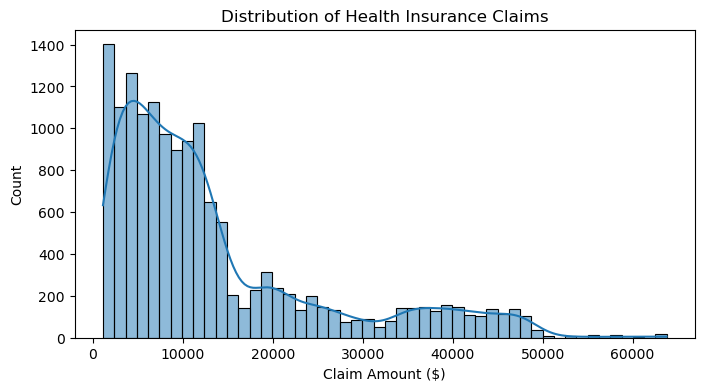

In [106]:
plt.subplots(figsize=(8, 4))
sns.histplot(df['claim'], kde=True, bins=50)
plt.title('Distribution of Health Insurance Claims')
plt.xlabel('Claim Amount ($)')
plt.ylabel('Count')
plt.show()

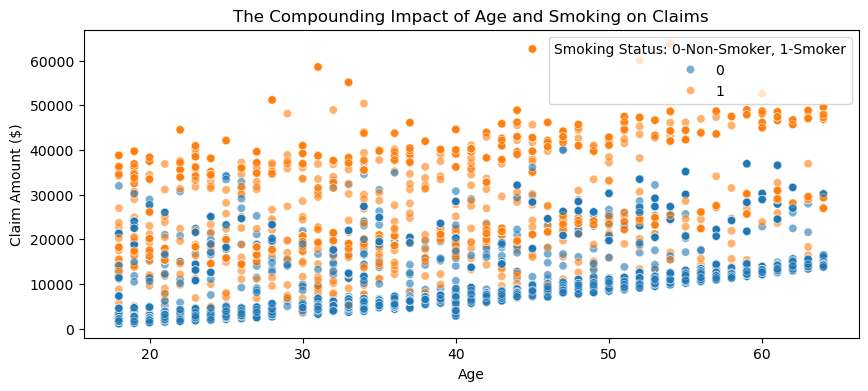

In [107]:
plt.subplots(figsize=(10, 4))
sns.scatterplot(data=df, x='age', y='claim', hue='smoker', alpha=0.6)
plt.title('The Compounding Impact of Age and Smoking on Claims')
plt.xlabel('Age')
plt.ylabel('Claim Amount ($)')
plt.legend(title='Smoking Status: 0-Non-Smoker, 1-Smoker')
plt.show()

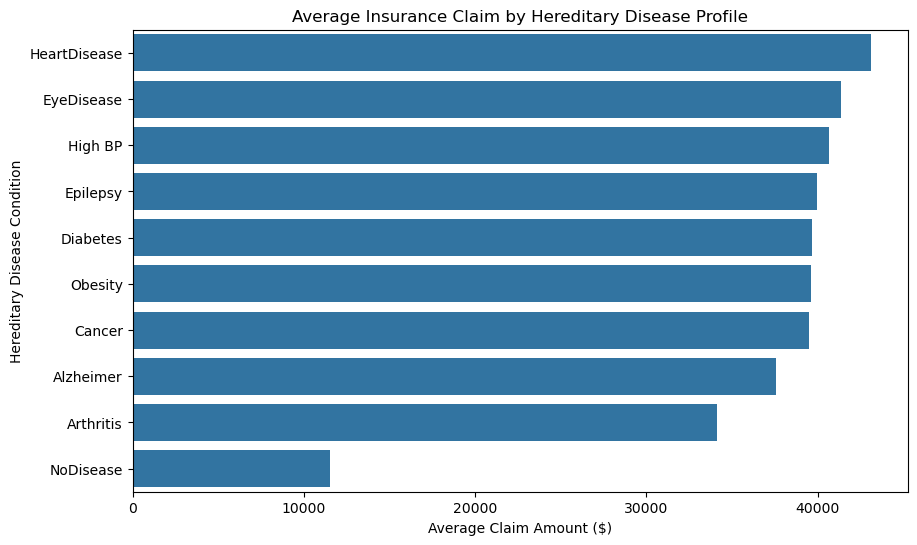

In [109]:
disease_order = df.groupby('hereditary_diseases')['claim'].mean().sort_values(ascending=False).index
plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='claim', y='hereditary_diseases', order=disease_order, errorbar=None)
plt.title('Average Insurance Claim by Hereditary Disease Profile')
plt.xlabel('Average Claim Amount ($)')
plt.ylabel('Hereditary Disease Condition')
plt.show()

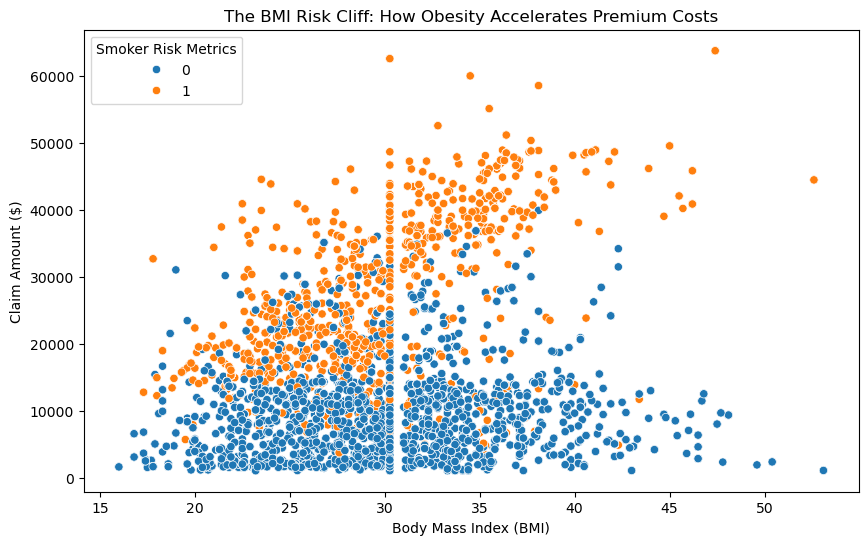

In [110]:
plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='claim', hue='smoker')
plt.title('The BMI Risk Cliff: How Obesity Accelerates Premium Costs')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Claim Amount ($)')
plt.legend(title='Smoker Risk Metrics')
plt.show()

<Axes: xlabel='bmi', ylabel='claim'>

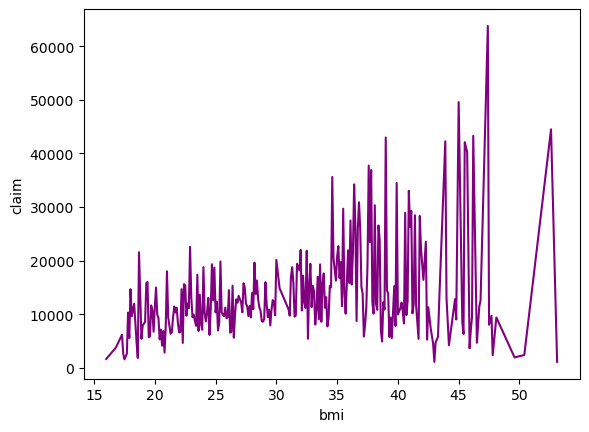

In [111]:
sns.lineplot(data=df,y='claim',x='bmi',errorbar=None,color='purple')

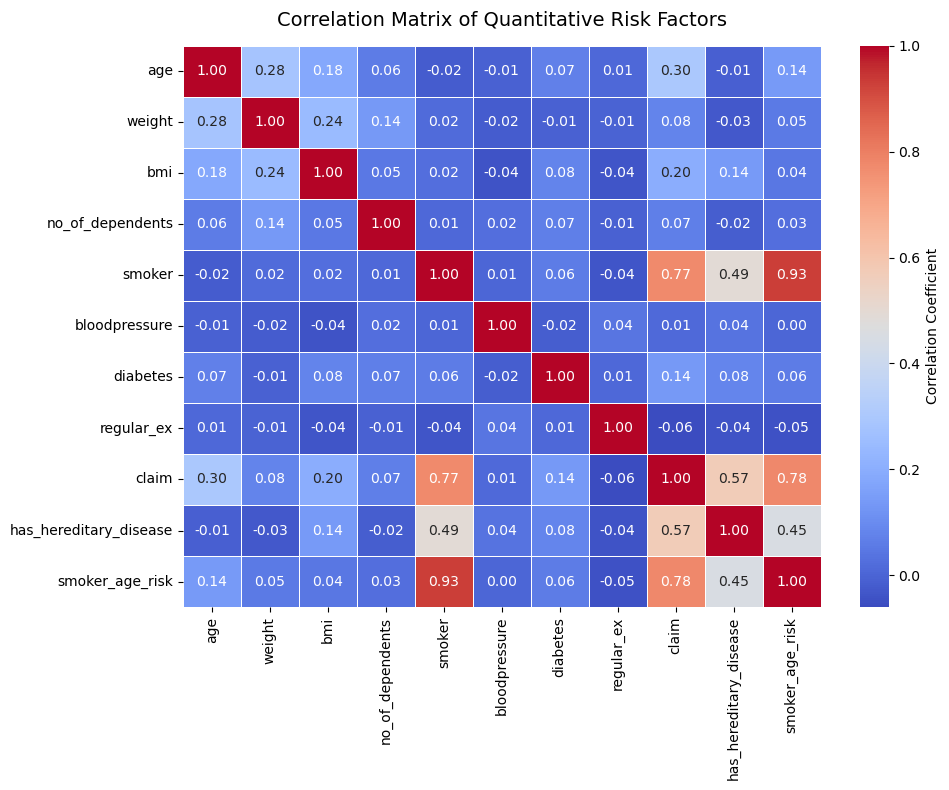

In [112]:
plt.subplots(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Quantitative Risk Factors', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=300)
plt.show()

In [114]:
df.to_csv(r'C:\Users\obian\OneDrive\Documents\SJ Lytix Projects\Smartcare\processed_data.csv',index=False)